# Simple Dot Product Attention for One Vector
- Visualizes the input embedding vectors
- generates simple dot product attention (without trainable weights) for one vector
- Uses softmax to normalize the dot product attention scores to get attention weights
- Generate the context vector for the word big
- Visualize the input vectors, weighted input vectors, and context vector for the word big

In [1]:
import torch
import numpy as np

## Input Vectors

In [2]:
# Words
words = ['Dream', 'big', 'and', 'work', 'for', 'it']

# Input Vectors corresponding to the words
inputs = torch.tensor(
    [[0.72, 0.45, 0.31], # dream
     [0.75,0.20,0.55],   # big
     [0.30,0.80,0.40],   # and
     [0.85,0.35,0.60],   # work
     [0.55,0.15,0.75],   # for
     [0.25,0.20,0.85]]   # it
)

## Magnitude of Input Vectors

In [3]:
# Calculate the magnitude of each vector
magnitudes = torch.norm(inputs, dim =1)

# Print the magnitudes
print("Magnitudes of the vectors:")
for word, magnitude in zip(words, magnitudes):
    print(f"{word}: {magnitude.item():.4f}")
    

Magnitudes of the vectors:
Dream: 0.9039
big: 0.9513
and: 0.9434
work: 1.0977
for: 0.9421
it: 0.9083


## Plot the 3D Input Vectors

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_vectors(inputs, words, colors, widths):
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection='3d')

    x_coords = inputs[:,0].numpy()
    y_coords = inputs[:,1].numpy()
    z_coords = inputs[:,2].numpy()

    for x, y, z, word, color, lw in zip(x_coords, y_coords, z_coords, words, colors,widths):
        ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05, linewidth =lw)
        ax.text(x, y, z, word, fontsize=10, color=color)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Automatically scale axes
    ax.set_xlim([0, max(x_coords)*1.1])
    ax.set_ylim([0, max(y_coords)*1.1])
    ax.set_zlim([0, max(z_coords)*1.1])

    plt.title('3D Plot of Input Vectors (Word Embeddings)')
    plt.show()

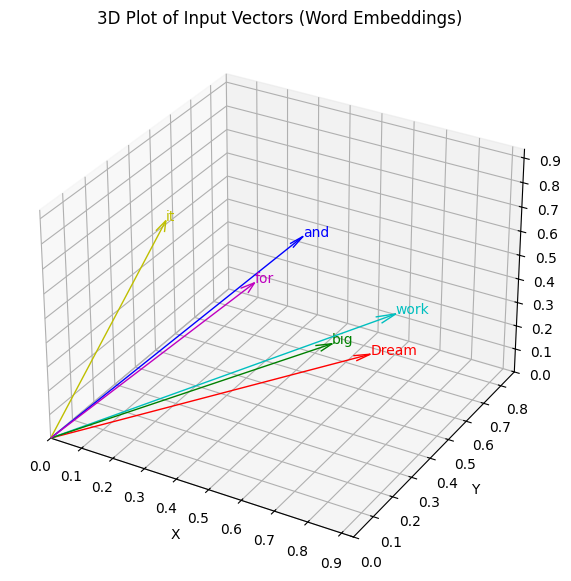

In [5]:
# 3D plot with vectors from origin
colors = ['r', 'g', 'b', 'c', 'm', 'y']
widths = [1.,1.,1.,1.,1.,1.]
plot_3d_vectors(inputs, words,colors,widths)

Question : Based on the plot above. Which word should Dream pay the least attention to ?
Answer: It. 'It' is pointing in a completely different direction.

KSW imo a dot product will caputure similarity.
you could use cosine similarity as well ??? but cosine similarity will eliminate the magnitude



## Simple Dot Product Attention: Context vector for one single word
Visualize it as well
Let's do this for the word 'Big'

### Dot Product Attention: Attention Scores

In [6]:
import torch.nn.functional as F

# Dot product of the word "Big" with all other vectors
# @ Does matrix multiplicaation . This is much faster than using for loops
# Note inputs[1].T i.e. transpose not necessary. Pytorch can infer this automatically
# dot_products is the attention_score

dot_products = inputs @ inputs[1]
print("dot_products:", dot_products)
print("dot_products.sum():",dot_products.sum())



dot_products: tensor([0.8005, 0.9050, 0.6050, 1.0375, 0.8550, 0.6950])
dot_products.sum(): tensor(4.8980)


### L1 Normalization
🧠 What this means
Notice that the sum is 1.
Magnitude is not 1 though.

In [7]:
# Scale the dot_product using L1 norm
dot_products_l1 = F.normalize(dot_products, p=1, dim=0)
dot_products_l1_magnitude = torch.norm(dot_products_l1, p=2)
print("dot_products_l1:", dot_products_l1)
print("dot_products_l1.sum():",dot_products_l1.sum())
print("dot_products_l1_magnitude:",dot_products_l1_magnitude)

dot_products_l1: tensor([0.1634, 0.1848, 0.1235, 0.2118, 0.1746, 0.1419])
dot_products_l1.sum(): tensor(1.0000)
dot_products_l1_magnitude: tensor(0.4142)


### L2 Normalization
🧠 What this means
Notice that the sum is NOT 1.
Magnitude is 1.

In [8]:
# Scale the dot_product using L2 norm
dot_products_l2 = F.normalize(dot_products, p=2, dim=0)
dot_products_l2_magnitude = torch.norm(dot_products_l2, p=2)
print("dot_products_l2:", dot_products_l2)
print("dot_products_l2.sum():",dot_products_l2.sum())
print("dot_products_l2_magnitude:",dot_products_l2_magnitude)

dot_products_l2: tensor([0.3946, 0.4461, 0.2982, 0.5114, 0.4214, 0.3426])
dot_products_l2.sum(): tensor(2.4142)
dot_products_l2_magnitude: tensor(1.0000)


## Softmax Normalization : Attention Weights
Notice that the sum is 1.
Magnitude is not 1 though.
This output is the attention weights

In [9]:
dot_products_softmax = F.softmax(dot_products, dim=0)
dot_products_softmax_magnitude = torch.norm(dot_products_softmax, p=2)
print("dot_products_softmax:", dot_products_softmax)
print("dot_products_softmax.sum():",dot_products_softmax.sum())
print("dot_products_softmax_magnitude:",dot_products_softmax_magnitude)

dot_products_softmax: tensor([0.1624, 0.1803, 0.1336, 0.2059, 0.1715, 0.1462])
dot_products_softmax.sum(): tensor(1.0000)
dot_products_softmax_magnitude: tensor(0.4122)


### Bar Chart Visualization

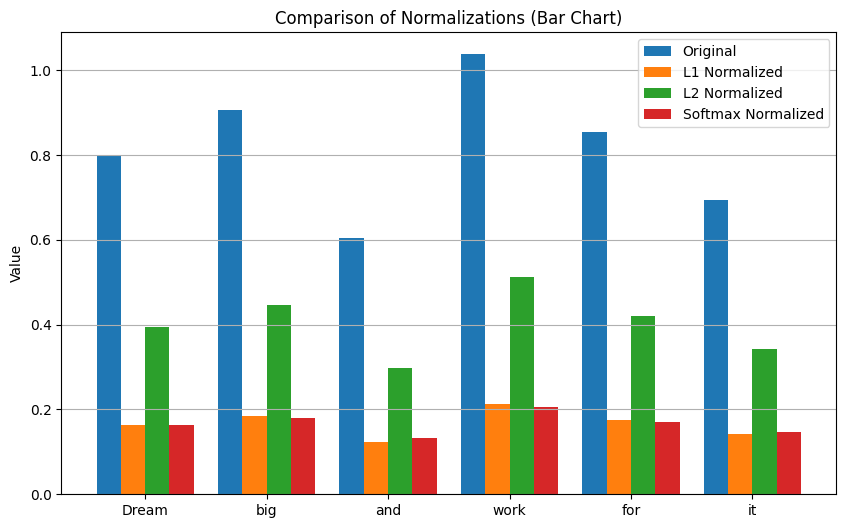

In [10]:
# Labels
labels = words
x_pos = np.arange(len(labels))

# Width of bars
width = 0.2

# Plot
plt.figure(figsize=(10,6))
plt.bar(x_pos - width,  dot_products,         width=width, label='Original')
plt.bar(x_pos,          dot_products_l1,      width=width, label='L1 Normalized')
plt.bar(x_pos + width,  dot_products_l2,      width=width, label='L2 Normalized')
plt.bar(x_pos + 2*width,dot_products_softmax, width=width, label='Softmax Normalized')

plt.xticks(x_pos + width/2, labels)
plt.ylabel('Value')
plt.title('Comparison of Normalizations (Bar Chart)')
plt.legend()
plt.grid(axis='y')
plt.show()

## Context vector for big
- Weighted addition of input vectors . The weights are the attention weights 
- Scale the input vectors for big using the attention weights for big (i.e. dot_products_softmax)
- visualize them

In [11]:
## Scale the inputs using the attention weights for big
# * is the pairwise product
scaled_input_vectors = inputs * dot_products_softmax.unsqueeze(1)

# Create the context vector for 'big' by adding the scaled input vectors
context_vector = torch.sum(scaled_input_vectors, dim=0).unsqueeze(0)

print("input embedding vectors :\n", inputs)
print("\n dot_products_softmax, for the word big:",dot_products_softmax)
print("\n scaled_input_vectors for the word  big:\n", scaled_input_vectors)
print("\n context_vector for the word  big:\n", context_vector)

input embedding vectors :
 tensor([[0.7200, 0.4500, 0.3100],
        [0.7500, 0.2000, 0.5500],
        [0.3000, 0.8000, 0.4000],
        [0.8500, 0.3500, 0.6000],
        [0.5500, 0.1500, 0.7500],
        [0.2500, 0.2000, 0.8500]])

 dot_products_softmax, for the word big: tensor([0.1624, 0.1803, 0.1336, 0.2059, 0.1715, 0.1462])

 scaled_input_vectors for the word  big:
 tensor([[0.1170, 0.0731, 0.0504],
        [0.1353, 0.0361, 0.0992],
        [0.0401, 0.1069, 0.0534],
        [0.1750, 0.0721, 0.1235],
        [0.0943, 0.0257, 0.1287],
        [0.0365, 0.0292, 0.1243]])

 context_vector for the word  big:
 tensor([[0.5982, 0.3431, 0.5794]])


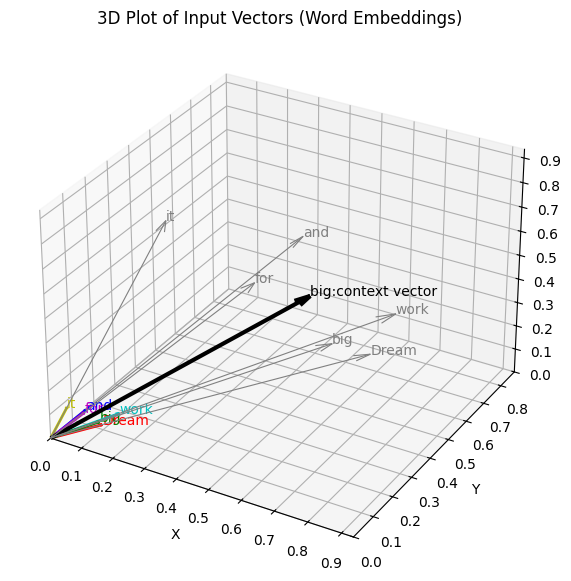

In [12]:
input_vector_colors  = ['grey']*6
scaled_input_vector_colors = colors
context_vector_color = ['black']

input_vector_widths = [0.8 * x for x in widths]
scaled_input_vector_widths = [2. * x for x in widths]
context_vector_width = [3]

inp = torch.cat((inputs, scaled_input_vectors, context_vector), dim=0)
wor = words + words + ['big:context vector']
col = input_vector_colors + scaled_input_vector_colors + context_vector_color
wid = input_vector_widths + scaled_input_vector_widths + context_vector_width

plot_3d_vectors(inp, wor,col,wid)